In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


stats = pd.read_csv('data/compiled_stats.csv')
stats

,Publication Date,Publication Year,Title,Author,Pronoun,Edited by,Edited by 2,Series,Type,Category,Subcategory,Subsubcategory,Word Count,Page Count
0,20-Jul-08,2008,The Leviathan,Wesley Allsbrook,She/her,NaN,NaN,NaN,Comics,NaN,NaN,NaN,NaN,14
1,20-Jul-08,2008,Down on the Farm,Charles Stross,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,Lovecraftian,NaN,12682.0,NaN
2,20-Jul-08,2008,After the Coup,John Scalzi,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Science Fiction,Space Opera,NaN,7087.0,NaN
3,5-Aug-08,2008,Old Flames Flare for Sweetie 'n Me,Joel Priddy,He/him,NaN,NaN,NaN,Comics,NaN,NaN,NaN,NaN,13
4,6-Aug-08,2008,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,NaN,NaN,NaN,15708.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,11/8/23,2023,Some Ways to Retell a Fairy Tale,Kathleen Jennings,she/her,NaN,NaN,NaN,Original Fiction,NaN,NaN,NaN,1157.0,NaN
870,11/15/23,2023,A Heart Between Teeth,Kerstin Hall,She/her,Kaleb Russell,NaN,NaN,Original Fiction,NaN,NaN,NaN,13889.0,NaN
871,12/6/23,2023,Sun River,Nisi Shawl,They/them,Nancy Lambert,NaN,NaN,Original Fiction,NaN,NaN,NaN,7110.0,NaN
872,12/8/23,2023,"Ivy, Angelica, Bay",C. L. Polk,They/them,Ruoxi Chen,NaN,NaN,Original Fiction,NaN,NaN,NaN,12980.0,NaN


### Filter to just fiction (exclude comics for now)

In [13]:
original_fiction = stats[stats['Type']=="Original Fiction"]
original_fiction

,Publication Date,Publication Year,Title,Author,Pronoun,Edited by,Edited by 2,Series,Type,Category,Subcategory,Subsubcategory,Word Count,Page Count
1,20-Jul-08,2008,Down on the Farm,Charles Stross,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,Lovecraftian,NaN,12682.0,NaN
2,20-Jul-08,2008,After the Coup,John Scalzi,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Science Fiction,Space Opera,NaN,7087.0,NaN
4,6-Aug-08,2008,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,NaN,NaN,NaN,15708.0,NaN
5,26-Aug-08,2008,Shade,Steven Gould,He/him,NaN,NaN,NaN,Original Fiction,NaN,NaN,NaN,5619.0,NaN
6,11-Sep-08,2008,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,NaN,NaN,5706.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,11/8/23,2023,Some Ways to Retell a Fairy Tale,Kathleen Jennings,she/her,NaN,NaN,NaN,Original Fiction,NaN,NaN,NaN,1157.0,NaN
870,11/15/23,2023,A Heart Between Teeth,Kerstin Hall,She/her,Kaleb Russell,NaN,NaN,Original Fiction,NaN,NaN,NaN,13889.0,NaN
871,12/6/23,2023,Sun River,Nisi Shawl,They/them,Nancy Lambert,NaN,NaN,Original Fiction,NaN,NaN,NaN,7110.0,NaN
872,12/8/23,2023,"Ivy, Angelica, Bay",C. L. Polk,They/them,Ruoxi Chen,NaN,NaN,Original Fiction,NaN,NaN,NaN,12980.0,NaN


### Check for duplicate titles

In [22]:
value_counts = original_fiction['Title'].value_counts().to_frame().reset_index()
value_counts

,Title,count
0,The City Quiet as Death,2
1,Zeppelin City,2
2,The Starship Mechanic,2
3,Looking for Truth in a Wild Blue Yonder,2
4,Intersections and Interlopers,2
...,...,...
634,Some Ways to Retell a Fairy Tale,1
635,A Heart Between Teeth,1
636,Sun River,1
637,"Ivy, Angelica, Bay",1


### Append the author count so that stories with multiple authors are not double counted

In [24]:
original_fiction = original_fiction.merge(value_counts[['Title', 'count']], on='Title', how='left')
original_fiction

,Publication Date,Publication Year,Title,Author,Pronoun,Edited by,Edited by 2,Series,Type,Category,Subcategory,Subsubcategory,Word Count,Page Count,count
0,20-Jul-08,2008,Down on the Farm,Charles Stross,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,Lovecraftian,NaN,12682.0,NaN,1
1,20-Jul-08,2008,After the Coup,John Scalzi,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Science Fiction,Space Opera,NaN,7087.0,NaN,1
2,6-Aug-08,2008,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,NaN,NaN,NaN,15708.0,NaN,1
3,26-Aug-08,2008,Shade,Steven Gould,He/him,NaN,NaN,NaN,Original Fiction,NaN,NaN,NaN,5619.0,NaN,1
4,11-Sep-08,2008,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,NaN,NaN,5706.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,11/8/23,2023,Some Ways to Retell a Fairy Tale,Kathleen Jennings,she/her,NaN,NaN,NaN,Original Fiction,NaN,NaN,NaN,1157.0,NaN,1
657,11/15/23,2023,A Heart Between Teeth,Kerstin Hall,She/her,Kaleb Russell,NaN,NaN,Original Fiction,NaN,NaN,NaN,13889.0,NaN,1
658,12/6/23,2023,Sun River,Nisi Shawl,They/them,Nancy Lambert,NaN,NaN,Original Fiction,NaN,NaN,NaN,7110.0,NaN,1
659,12/8/23,2023,"Ivy, Angelica, Bay",C. L. Polk,They/them,Ruoxi Chen,NaN,NaN,Original Fiction,NaN,NaN,NaN,12980.0,NaN,1


### For stories with 2 authors, divide the word count in 2.

This will mean that stories written by authors using different pronouns will assign number of words equally to each pronoun

In [27]:
original_fiction['adjusted_count'] = original_fiction['Word Count']/original_fiction['count']
original_fiction[original_fiction['count']==2]

,Publication Date,Publication Year,Title,Author,Pronoun,Edited by,Edited by 2,Series,Type,Category,Subcategory,Subsubcategory,Word Count,Page Count,count,adjusted_count
17,9-Jun-09,2009,The City Quiet as Death,Michael Bishop,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,Lovecraftian,NaN,5890.0,NaN,2,2945.0
18,9-Jun-09,2009,The City Quiet as Death,Steven Utley,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Fantasy,Lovecraftian,NaN,5890.0,NaN,2,2945.0
25,6-Oct-09,2009,Zeppelin City,Michael Swanwick,He/him,Patrick Nielsen Hayden,NaN,Steampunk Month,Original Fiction,Science Fiction,Steampunk,NaN,14271.0,NaN,2,7135.5
26,6-Oct-09,2009,Zeppelin City,Eileen Gunn,She/her,Patrick Nielsen Hayden,NaN,Steampunk Month,Original Fiction,Science Fiction,Steampunk,NaN,14271.0,NaN,2,7135.5
34,13-Jan-10,2010,The Starship Mechanic,Jay Lake,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Humor,Science Fiction,NaN,2220.0,NaN,2,1110.0
35,13-Jan-10,2010,Looking for Truth in a Wild Blue Yonder,Jay Lake,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Humor,Science Fiction,NaN,2019.0,NaN,2,1009.5
36,13-Jan-10,2010,The Starship Mechanic,Ken Scholes,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Humor,Science Fiction,NaN,2220.0,NaN,2,1110.0
37,13-Jan-10,2010,Looking for Truth in a Wild Blue Yonder,Ken Scholes,He/him,Patrick Nielsen Hayden,NaN,NaN,Original Fiction,Humor,Science Fiction,NaN,2019.0,NaN,2,1009.5
57,29-Sep-10,2010,Intersections and Interlopers,Ken Scholes,He/him,Beth Meacham,NaN,NaN,Original Fiction,Fantasy,Urban Fantasy,NaN,1633.0,NaN,2,816.5
59,29-Sep-10,2010,Intersections and Interlopers,Lisa Desrochers,She/her,Beth Meacham,NaN,NaN,Original Fiction,Fantasy,Urban Fantasy,NaN,1633.0,NaN,2,816.5


### Filter to just the columns needed at this time: year, pronouns, and (adjusted) word count

In [28]:
var_list = ['Publication Year', 'Pronoun', 'adjusted_count']
df = original_fiction[var_list]
df

,Publication Year,Pronoun,adjusted_count
0,2008,He/him,12682.0
1,2008,He/him,7087.0
2,2008,He/him,15708.0
3,2008,He/him,5619.0
4,2008,She/her,5706.0
...,...,...,...
656,2023,she/her,1157.0
657,2023,She/her,13889.0
658,2023,They/them,7110.0
659,2023,They/them,12980.0


### Rename columns for simplicity

In [31]:
df.columns = ['year', 'pronouns', 'words']
df

,year,pronouns,words
0,2008,He/him,12682.0
1,2008,He/him,7087.0
2,2008,He/him,15708.0
3,2008,He/him,5619.0
4,2008,She/her,5706.0
...,...,...,...
656,2023,she/her,1157.0
657,2023,She/her,13889.0
658,2023,They/them,7110.0
659,2023,They/them,12980.0


### Make all pronouns lowercase

This will prevent entries like "She/Her", "She/her", and "she/her" from being treated as different values.

In [32]:
df['pronouns'] = df['pronouns'].str.lower()
df

,year,pronouns,words
0,2008,he/him,12682.0
1,2008,he/him,7087.0
2,2008,he/him,15708.0
3,2008,he/him,5619.0
4,2008,she/her,5706.0
...,...,...,...
656,2023,she/her,1157.0
657,2023,she/her,13889.0
658,2023,they/them,7110.0
659,2023,they/them,12980.0


### Generate data for publication count by pronouns and year

**Note**: Publications with two authors will appear twice in these totals

In [37]:
pub_count = df.value_counts(['year', 'pronouns']).to_frame().reset_index().sort_values(['year', 'pronouns'])
pub_count

,year,pronouns,count
27,2008,he/him,8
37,2008,she/her,1
15,2009,he/him,18
28,2009,she/her,7
13,2010,he/him,21
16,2010,she/her,18
11,2011,he/him,23
29,2011,she/her,6
38,2011,they/them,1
17,2012,he/him,18


### Generate graph of publication count by pronouns and year

**Note**: Publications with two authors will appear twice in these totals

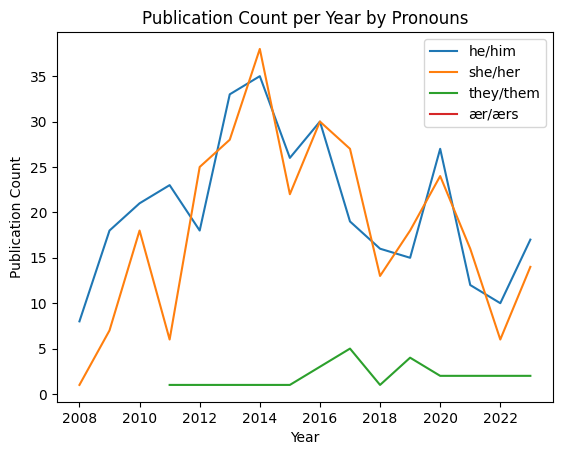

In [ ]:
for key, grp in pub_count.groupby('pronouns'):
    plt.plot(grp['year'], grp['count'], label=key)

plt.xlabel('Year')
plt.ylabel('Publication Count')
plt.title('Publication Count per Year by Pronouns')
plt.legend()
plt.show()

### Generate data for word count by pronouns and year

In [39]:
word_count = df.groupby(['year', 'pronouns'])['words'].sum().reset_index().sort_values(['year', 'pronouns'])
word_count

,year,pronouns,words
0,2008,he/him,73144.0
1,2008,she/her,5706.0
2,2009,he/him,101329.5
3,2009,she/her,60465.5
4,2010,he/him,94713.5
5,2010,she/her,82220.5
6,2011,he/him,169527.0
7,2011,she/her,27716.0
8,2011,they/them,9703.0
9,2012,he/him,108775.0


### Graph of word count by pronouns and year

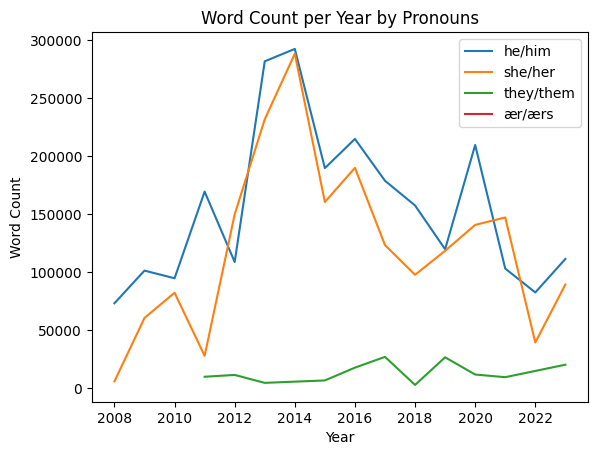

In [40]:
for key, grp in word_count.groupby('pronouns'):
    plt.plot(grp['year'], grp['words'], label=key)

plt.xlabel('Year')
plt.ylabel('Word Count')
plt.title('Word Count per Year by Pronouns')
plt.legend()
plt.show()